# Sinkhorn marginal error for several regularizations

This notebook generates `fig:sinkhorn-linear-rate-epsilon`.  For fixed $\varepsilon>0$, Sinkhorn scaling converges linearly once the positive kernel has entered its asymptotic regime.  The figure plots the total marginal violation
$$
E_k=\frac12\left(\lVert P_k\mathbf 1-a\rVert_1+\lVert P_k^\top\mathbf 1-b\rVert_1\right)
$$
after each half-step, for several values of $\varepsilon$.  This is a small pedagogical diagnostic, not a benchmark comparison.

In [1]:

from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        break
else:
    raise RuntimeError("Could not locate figure_style.py")

import matplotlib.pyplot as plt
import numpy as np
import ot

from figure_style import BLUE, RED, VIOLET, GRAY, LIGHT_GRAY, ORANGE, box_axes, coupling_box, figure_dir, remove_axes, save_pdf, setup_matplotlib

setup_matplotlib()
np.random.seed(0)

def normal_pdf(x, mean, std):
    return np.exp(-0.5 * ((x - mean) / std) ** 2) / (std * np.sqrt(2 * np.pi))


def mixture_pdf(x, weights, means, stds):
    out = np.zeros_like(x, dtype=float)
    for w, m, s in zip(weights, means, stds):
        out += w * normal_pdf(x, m, s)
    return out


def sinkhorn_histograms(n=90):
    grid = np.linspace(-3.25, 3.15, n)
    alpha_density = mixture_pdf(grid, [0.58, 0.42], [-1.95, -0.10], [0.34, 0.54])
    beta_density = mixture_pdf(grid, [0.42, 0.58], [-0.75, 1.55], [0.42, 0.36])
    a = alpha_density / alpha_density.sum()
    b = beta_density / beta_density.sum()
    C = (grid[:, None] - grid[None, :]) ** 2
    C = C / np.median(C[C > 0])
    return grid, alpha_density, beta_density, a, b, C


def scaling_states(K, a, b, n_full=40):
    P = K / K.sum()
    out = [('initial', P.copy())]
    for k in range(1, n_full + 1):
        P = (a / np.maximum(P.sum(axis=1), 1e-300))[:, None] * P
        out.append((f'row-{k}', P.copy()))
        P = P * (b / np.maximum(P.sum(axis=0), 1e-300))[None, :]
        out.append((f'column-{k}', P.copy()))
    return out


def sinkhorn_error_curves(a, b, C, epsilons, n_iter=130):
    curves = []
    for eps in epsilons:
        K = np.exp(-C / eps)
        P = K / K.sum()
        errs = [0.5 * (np.abs(P.sum(axis=1)-a).sum() + np.abs(P.sum(axis=0)-b).sum())]
        for _ in range(n_iter):
            P = (a / np.maximum(P.sum(axis=1), 1e-300))[:, None] * P
            errs.append(0.5 * (np.abs(P.sum(axis=1)-a).sum() + np.abs(P.sum(axis=0)-b).sum()))
            P = P * (b / np.maximum(P.sum(axis=0), 1e-300))[None, :]
            errs.append(0.5 * (np.abs(P.sum(axis=1)-a).sum() + np.abs(P.sum(axis=0)-b).sum()))
        curves.append((eps, np.asarray(errs)))
    return curves


def matrix_with_marginal_curves(P, a, b, path, *, gamma=0.45, show_current=True, compact=False, vmax=None, box_color="#2b2b2b"):
    n, m = P.shape
    fig, ax = plt.subplots(figsize=(2.18, 2.04) if not compact else (2.05, 1.95))
    scale = max(float(P.max() if vmax is None else vmax), 1e-15)
    image = np.clip(P / scale, 0, 1)
    ax.imshow(image ** gamma, cmap='Greys', origin='lower', extent=(-0.5, m-0.5, -0.5, n-0.5), interpolation='nearest', vmin=0, vmax=1, aspect='auto')

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_frame_on(False)
    coupling_box(ax, n, m, color=box_color, linewidth=0.58)

    row = P.sum(axis=1)
    col = P.sum(axis=0)
    left_base = -0.5 - 0.026 * m
    top_base = n - 0.5 + 0.026 * n
    left_scale = 0.13 * m / max(a.max(), row.max(), 1e-15)
    top_scale = 0.13 * n / max(b.max(), col.max(), 1e-15)
    yy = np.arange(n)
    xx = np.arange(m)

    ax.plot(left_base - left_scale * a, yy, color=RED, lw=0.95, zorder=4)
    ax.fill_betweenx(yy, left_base, left_base - left_scale * a, color=RED, alpha=0.12, linewidth=0, zorder=3)
    ax.plot(xx, top_base + top_scale * b, color=BLUE, lw=0.95, zorder=4)
    ax.fill_between(xx, top_base, top_base + top_scale * b, color=BLUE, alpha=0.12, linewidth=0, zorder=3)

    if show_current:
        ax.plot(left_base - left_scale * row, yy, color=VIOLET, lw=0.80, alpha=0.90, zorder=5)
        ax.fill_betweenx(yy, left_base, left_base - left_scale * row, color=VIOLET, alpha=0.12, linewidth=0, zorder=4)
        ax.plot(xx, top_base + top_scale * col, color=VIOLET, lw=0.80, alpha=0.90, zorder=5)
        ax.fill_between(xx, top_base, top_base + top_scale * col, color=VIOLET, alpha=0.12, linewidth=0, zorder=4)

    ax.set_xlim(-0.5 - 0.18 * m, m - 0.5)
    ax.set_ylim(-0.5, n - 0.5 + 0.18 * n)
    ax.set_xticks([])
    ax.set_yticks([])
    save_pdf(fig, path, pad_inches=0.04)
    plt.close(fig)


def sinkhorn_plan(a, b, C, eps):
    plan = ot.sinkhorn(
        a,
        b,
        C,
        reg=eps,
        method="sinkhorn_log",
        numItermax=50000,
        stopThr=1e-12,
    )
    plan = np.asarray(plan, dtype=float)
    residual = max(np.abs(plan.sum(axis=1) - a).sum(), np.abs(plan.sum(axis=0) - b).sum())
    if residual > 2e-7:
        raise RuntimeError(f"Sinkhorn did not converge for epsilon={eps}: residual={residual:.2e}")
    return plan


def draw_plan_gallery(plans, colors, path, *, gamma=0.44):
    fig, axes = plt.subplots(2, 2, figsize=(1.72, 1.72))
    vmax = max(float(P.max()) for _, P in plans)
    for ax, (eps, P), color in zip(axes.ravel(), plans, colors):
        n, m = P.shape
        image = np.clip(P / max(vmax, 1e-15), 0, 1)
        ax.imshow(
            image ** gamma,
            cmap="Greys",
            origin="lower",
            extent=(-0.5, m - 0.5, -0.5, n - 0.5),
            interpolation="nearest",
            vmin=0,
            vmax=1,
            aspect="auto",
        )
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_frame_on(False)
        coupling_box(ax, n, m, color=color, linewidth=0.80)
        ax.set_xlim(-0.5, m - 0.5)
        ax.set_ylim(-0.5, n - 0.5)
        ax.set_xticks([])
        ax.set_yticks([])
    fig.subplots_adjust(left=0.02, right=0.98, bottom=0.02, top=0.98, wspace=0.07, hspace=0.07)
    save_pdf(fig, path, pad_inches=0.018)
    plt.close(fig)

fig_name = "sinkhorn-linear-rate-epsilon"
out = figure_dir(fig_name)


## Error curves

The same one-dimensional histograms are used throughout the Sinkhorn section.  Smaller $\varepsilon$ makes the Gibbs kernel more peaked; this improves the geometric approximation to unregularized OT but slows down matrix scaling.

In [2]:

grid, alpha_density, beta_density, a, b, C = sinkhorn_histograms(n=90)
epsilons = [0.020, 0.045, 0.090, 0.180]
curves = sinkhorn_error_curves(a, b, C, epsilons, n_iter=100)
colors = [RED, VIOLET, ORANGE, BLUE]
limiting_plans = [(eps, sinkhorn_plan(a, b, C, eps)) for eps in epsilons]
draw_plan_gallery(limiting_plans, colors, out / "limiting-plans.pdf")

fig, ax = plt.subplots(figsize=(3.25, 2.05))
for (eps, err), color in zip(curves, colors):
    err = np.maximum(err, 1e-15)
    ax.plot(np.arange(len(err)), err, color=color, lw=1.18)
    # Put a small intrinsic label at the final readable part of the curve.
    idx = min(len(err)-1, 150)
    ax.text(idx + 2, err[idx], f"$\\varepsilon={eps:.3f}$", color=color, fontsize=6.5, va='center')
ax.set_yscale('log')
ax.set_xlim(0, 205)
ax.set_ylim(3e-13, 1.2)
ax.tick_params(axis='both', labelsize=6, pad=1.5)
ax.grid(True, which='major', color=LIGHT_GRAY, lw=0.45, alpha=0.72)
box_axes(ax)
save_pdf(fig, out / 'marginal-error.pdf', pad_inches=0.045)
plt.close(fig)


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


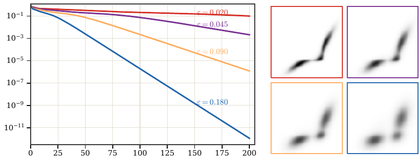

In [3]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/sinkhorn-linear-rate-epsilon.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/sinkhorn-linear-rate-epsilon.png")
display(Image(filename=str(_thumb)))
